In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU found: {gpu_name}')
    print(f'RAM total: {vram_total:.1f} GB')
    print(f'CUDA version: {torch.version.cuda}')
else:
    print(' No GPU!')


GPU found: Tesla T4
RAM total: 15.6 GB
CUDA version: 12.8


In [3]:

!pip install transformers peft bitsandbytes accelerate matplotlib -q
print('✅ Packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.9 MB/s eta 0:00:00
✅ Packages installed!


In [11]:


import os

BASE_MODEL = 'Qwen/Qwen2.5-1.5B-Instruct'

ADAPTER_PATH ="/content/drive/MyDrive/Colab Notebooks/Week8/adapters"


GGUF_PATH = "/content/drive/MyDrive/Colab Notebooks/Week8/quantized/model.gguf"


OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/Week8/benchmarks"
os.makedirs(OUTPUT_DIR, exist_ok=True)


print('CONFIGURATION:')
print(f'  Base model:   {BASE_MODEL} ✅')
print(f'  Adapter:      {ADAPTER_PATH} {"✅" if ADAPTER_PATH and os.path.exists(ADAPTER_PATH) else "❌ (not found — base model only)"}')
print(f'  GGUF:         {GGUF_PATH} {"✅" if GGUF_PATH and os.path.exists(GGUF_PATH) else "❌ (not found — CPU test skipped)"}')
print(f'  Output dir:   {OUTPUT_DIR} ✅')

CONFIGURATION:
  Base model:   Qwen/Qwen2.5-1.5B-Instruct ✅
  Adapter:      /content/drive/MyDrive/Colab Notebooks/Week8/adapters ✅
  GGUF:         /content/drive/MyDrive/Colab Notebooks/Week8/quantized/model.gguf ✅
  Output dir:   /content/drive/MyDrive/Colab Notebooks/Week8/benchmarks ✅


In [ ]:
import time
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

def get_vram_used_gb():
    if torch.cuda.is_available():
        return round(torch.cuda.memory_allocated() / 1e9, 2)
    return 0.0

def clear_gpu():

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def format_prompt(instruction, input_text=''):
    if input_text:
        return f'### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n'
    return f'### Instruction:\n{instruction}\n\n### Response:\n'

def measure_speed(model, tokenizer, prompt, n_new_tokens=60):
    """
    Tokens per second measure karo.

    Steps:
    1. Prompt tokenize karo
    2. GPU pe bhejo
    3. Time start karo
    4. Model se tokens generate karo
    5. Time stop karo
    6. Tokens / time = speed
    """
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=400)
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    input_len = inputs['input_ids'].shape[1]

    
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=5,
                           pad_token_id=tokenizer.eos_token_id)

    
    if torch.cuda.is_available(): torch.cuda.synchronize()
    start = time.perf_counter()

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=n_new_tokens,
            do_sample=False,          
            use_cache=True,            
            pad_token_id=tokenizer.eos_token_id,
        )

    if torch.cuda.is_available(): torch.cuda.synchronize()
    elapsed = time.perf_counter() - start

    new_tokens = output.shape[1] - input_len
    tps = new_tokens / elapsed if elapsed > 0 else 0

    
    response = tokenizer.decode(output[0][input_len:], skip_special_tokens=True)

    return {
        'tokens_per_sec': round(tps, 1),
        'latency_sec':    round(elapsed, 3),
        'new_tokens':     new_tokens,
        'response':       response.strip()
    }

print('✅ Helper functions ready!')


TEST_PROMPTS = [
    {
        'type': 'QA',
        'instruction': 'Give a concise and accurate explanation of the following medical term.',
        'input': 'What is meant by dehydration?'
    },
    {
        'type': 'Reasoning',
        'instruction': 'Interpret the following case in an educational and non-definitive way.',
        'input': 'A patient has fatigue, increased thirst, and frequent urination for 1 week. The symptoms are persistent.'
    },
    {
        'type': 'Extraction',
        'instruction': 'Identify and list the symptoms mentioned in the note.',
        'input': 'Clinical note: fever, cough, headache, and chest pain have been present for 5 days.'
    }
]

print(f'Test prompts ready: {len(TEST_PROMPTS)} prompts (QA + Reasoning + Extraction)')

✅ Helper functions ready!
Test prompts ready: 3 prompts (QA + Reasoning + Extraction)


In [ ]:

print('Loading BASE model (FP16, no fine-tuning)...')
clear_gpu()
vram_before = get_vram_used_gb()

tokenizer_base = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_base.pad_token = tokenizer_base.eos_token

model_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,   
    device_map='auto',           
)

vram_base = get_vram_used_gb() - vram_before
print(f'✅ Base model loaded!')
print(f'   VRAM used: {vram_base:.2f} GB')

Loading BASE model (FP16, no fine-tuning)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✅ Base model loaded!
   VRAM used: 3.09 GB


In [ ]:


base_results = []

print('Running benchmarks on BASE model...')


for p in TEST_PROMPTS:
    prompt_str = format_prompt(p['instruction'], p['input'])
    metrics = measure_speed(model_base, tokenizer_base, prompt_str)

    row = {
        'model':       'base',
        'type':        p['type'],
        'tokens_per_sec': metrics['tokens_per_sec'],
        'latency_sec': metrics['latency_sec'],
        'vram_gb':     vram_base,
        'response':    metrics['response'][:120]  
    }
    base_results.append(row)

    print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
          f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
    print(f"  Response: {metrics['response'][:100]}...")
    print()

avg_base_tps = sum(r['tokens_per_sec'] for r in base_results) / len(base_results)
print(f'BASE model average: {avg_base_tps:.1f} tok/s | VRAM: {vram_base:.2f} GB')


del model_base
clear_gpu()
print('\nGPU memory freed for next model ✅')

Running benchmarks on BASE model...
[QA        ]   18.9 tok/s | 3.17s | 60 tokens
  Response: Dehydration occurs when there isn't enough water in your body. This can happen if you lose too much ...

[Reasoning ]   22.9 tok/s | 2.62s | 60 tokens
  Response: The patient is experiencing a common set of symptoms that can be indicative of several conditions. T...

[Extraction]   25.2 tok/s | 1.70s | 43 tokens
  Response: The symptoms mentioned in the clinical note are:

1. Fever
2. Cough
3. Headache
4. Chest pain

These...

BASE model average: 22.3 tok/s | VRAM: 3.09 GB

GPU memory freed for next model ✅


In [ ]:


fine_tuned_results = []

if ADAPTER_PATH and os.path.exists(ADAPTER_PATH):
    print(f'Loading FINE-TUNED model (QLoRA adapter from {ADAPTER_PATH})...')
    clear_gpu()
    vram_before = get_vram_used_gb()

    
    bnb_4bit = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16,
    )

    tokenizer_ft = AutoTokenizer.from_pretrained(BASE_MODEL)
    tokenizer_ft.pad_token = tokenizer_ft.eos_token

    model_ft = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        quantization_config=bnb_4bit,
        device_map='auto',
    )

    
    from peft import PeftModel
    model_ft = PeftModel.from_pretrained(model_ft, ADAPTER_PATH)

    vram_ft = get_vram_used_gb() - vram_before
    print(f'✅ Fine-tuned model loaded!')
    print(f'   VRAM used: {vram_ft:.2f} GB')
    FT_AVAILABLE = True

else:
    print('⚠️  Adapter not found at:', ADAPTER_PATH)
    print('   SKIPPING fine-tuned benchmark')
    print('   (Set ADAPTER_PATH in Cell 3, or mount Drive in Cell 4)')
    vram_ft = 0
    FT_AVAILABLE = False

Loading FINE-TUNED model (QLoRA adapter from /content/drive/MyDrive/Colab Notebooks/Week8/adapters)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✅ Fine-tuned model loaded!
   VRAM used: 0.75 GB


In [17]:


if FT_AVAILABLE:
    print('Running benchmarks on FINE-TUNED model...')

    for p in TEST_PROMPTS:
        prompt_str = format_prompt(p['instruction'], p['input'])
        metrics = measure_speed(model_ft, tokenizer_ft, prompt_str)

        row = {
            'model':          'fine_tuned',
            'type':           p['type'],
            'tokens_per_sec': metrics['tokens_per_sec'],
            'latency_sec':    metrics['latency_sec'],
            'vram_gb':        vram_ft,
            'response':       metrics['response'][:120]
        }
        fine_tuned_results.append(row)

        print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
              f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
        print(f"  Response: {metrics['response'][:100]}...")
        print()

    avg_ft_tps = sum(r['tokens_per_sec'] for r in fine_tuned_results) / len(fine_tuned_results)
    print(f'FINE-TUNED average: {avg_ft_tps:.1f} tok/s | VRAM: {vram_ft:.2f} GB')

    del model_ft
    clear_gpu()
    print('\nGPU memory freed ✅')
else:
    print('Fine-tuned benchmark skipped (no adapter found)')

Running benchmarks on FINE-TUNED model...
[QA        ]    9.1 tok/s | 6.58s | 60 tokens
  Response: Dehydration occurs when there is an imbalance between fluid intake and output, leading to symptoms s...

[Reasoning ]    5.4 tok/s | 11.11s | 60 tokens
  Response: Possible Association: The symptom pattern of fatigue, increased thirst, frequent urination may be as...

[Extraction]    5.8 tok/s | 10.38s | 60 tokens
  Response: Symptoms: fever, cough, headache, chest pain Duration: 5 days Severity: present Duration: 5 days Sev...

FINE-TUNED average: 6.8 tok/s | VRAM: 0.75 GB

GPU memory freed ✅


In [18]:
print('Loading QUANTISED model (4-bit NF4, no adapter)...')
clear_gpu()
vram_before = get_vram_used_gb()

bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer_q4 = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_q4.pad_token = tokenizer_q4.eos_token

model_q4 = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_4bit,
    device_map='auto',
)

vram_q4 = get_vram_used_gb() - vram_before
print(f'✅ 4-bit model loaded!')
print(f'   VRAM used: {vram_q4:.2f} GB')

Loading QUANTISED model (4-bit NF4, no adapter)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

✅ 4-bit model loaded!
   VRAM used: 1.15 GB


In [19]:

quant_results = []

print('Running benchmarks on QUANTISED (4-bit) model...')

for p in TEST_PROMPTS:
    prompt_str = format_prompt(p['instruction'], p['input'])
    metrics = measure_speed(model_q4, tokenizer_q4, prompt_str)

    row = {
        'model':          'quantised_4bit',
        'type':           p['type'],
        'tokens_per_sec': metrics['tokens_per_sec'],
        'latency_sec':    metrics['latency_sec'],
        'vram_gb':        vram_q4,
        'response':       metrics['response'][:120]
    }
    quant_results.append(row)

    print(f"[{p['type']:10}] {metrics['tokens_per_sec']:6.1f} tok/s | "
          f"{metrics['latency_sec']:.2f}s | {metrics['new_tokens']} tokens")
    print(f"  Response: {metrics['response'][:100]}...")
    print()

avg_q4_tps = sum(r['tokens_per_sec'] for r in quant_results) / len(quant_results)
print(f'QUANTISED average: {avg_q4_tps:.1f} tok/s | VRAM: {vram_q4:.2f} GB')

del model_q4
clear_gpu()
print('\nGPU memory freed ✅')

Running benchmarks on QUANTISED (4-bit) model...
[QA        ]    8.0 tok/s | 7.54s | 60 tokens
  Response: Dehydration occurs when there is an imbalance between water intake and excretion, leading to a decre...

[Reasoning ]   12.1 tok/s | 4.96s | 60 tokens
  Response: The patient is experiencing a common set of symptoms that can be indicative of several different con...

[Extraction]   10.5 tok/s | 3.63s | 38 tokens
  Response: The symptoms mentioned in the note are:

1. Fever
2. Cough
3. Headache
4. Chest pain

These symptoms...

QUANTISED average: 10.2 tok/s | VRAM: 1.15 GB

GPU memory freed ✅


In [20]:

from transformers import TextStreamer

print('Loading model for streaming demo...')
tokenizer_s = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_s.pad_token = tokenizer_s.eos_token

model_stream = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
)

# Streaming prompt
prompt = format_prompt('What is Dehydration?')
inputs = tokenizer_s(prompt, return_tensors='pt').to('cuda')


streamer = TextStreamer(
    tokenizer_s,
    skip_prompt=True,
    skip_special_tokens=True
)


with torch.no_grad():
    model_stream.generate(
        **inputs,
        max_new_tokens=120,
        streamer=streamer,
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer_s.eos_token_id,
    )
print('\n--- STREAMING COMPLETE ---')

del model_stream
clear_gpu()

Loading model for streaming demo...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Dehydration occurs when the body loses more fluid than it takes in. This can happen through sweating, diarrhea, vomiting, or excessive urination. When this happens, the body's cells become dehydrated and start to shrink. Symptoms of dehydration include dry mouth, dizziness, headache, and fatigue. Mild dehydration can be treated with increased fluid intake, while severe cases may require medical attention. Prevention involves staying hydrated by drinking plenty of water throughout the day, especially during hot weather or physical activity.

--- STREAMING COMPLETE ---


In [21]:


print('Loading model for batch inference demo...')
tokenizer_b = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer_b.pad_token = tokenizer_b.eos_token
tokenizer_b.padding_side = 'left'

model_batch = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map='auto',
)


batch_prompts = [
    format_prompt('What is cough?'),
    format_prompt('What is anemia?'),
    format_prompt('Explain vomiting'),
]


inputs = tokenizer_b(
    batch_prompts,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=256,
)
inputs = {k: v.cuda() for k, v in inputs.items()}


start_seq = time.perf_counter()
for p in batch_prompts:
    inp = tokenizer_b(p, return_tensors='pt').to('cuda')
    with torch.no_grad():
        _ = model_batch.generate(**inp, max_new_tokens=50,
                                  pad_token_id=tokenizer_b.eos_token_id)
seq_time = time.perf_counter() - start_seq


if torch.cuda.is_available(): torch.cuda.synchronize()
start_batch = time.perf_counter()
with torch.no_grad():
    outputs = model_batch.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        pad_token_id=tokenizer_b.eos_token_id,
    )
if torch.cuda.is_available(): torch.cuda.synchronize()
batch_time = time.perf_counter() - start_batch

print(f'\nBATCH INFERENCE RESULTS ({len(batch_prompts)} prompts):')
print(f'  One by one:  {seq_time:.2f}s total | {seq_time/3:.2f}s per prompt')
print(f'  Batch:       {batch_time:.2f}s total | {batch_time/3:.2f}s per prompt')
print(f'  Speedup:     {seq_time/batch_time:.1f}x faster with batching!')

print('\nBatch outputs:')
for i, out in enumerate(outputs):
    inp_len = inputs['input_ids'].shape[1]
    resp = tokenizer_b.decode(out[inp_len:], skip_special_tokens=True)
    print(f'  Q{i+1}: {resp[:80]}...')

del model_batch
clear_gpu()

Loading model for batch inference demo...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


BATCH INFERENCE RESULTS (3 prompts):
  One by one:  7.27s total | 2.42s per prompt
  Batch:       2.59s total | 0.86s per prompt
  Speedup:     2.8x faster with batching!

Batch outputs:
  Q1: Coughing is a reflex action that helps clear the throat and lungs of irritants, ...
  Q2: Anemia is a condition in which the number of red blood cells or hemoglobin level...
  Q3: Vomiting is a common symptom that can be caused by various factors, including il...


In [22]:


!pip install llama-cpp-python --prefer-binary -q
print('✅ llama-cpp-python installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 MB 11.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.9 MB/s eta 0:00:00
✅ llama-cpp-python installed!


In [23]:

gguf_tps = None

if GGUF_PATH and os.path.exists(GGUF_PATH):
    try:
        from llama_cpp import Llama

        print(f'Loading GGUF from: {GGUF_PATH}')
        print('Running on CPU — no GPU used!')

        llm = Llama(
            model_path=GGUF_PATH,
            n_ctx=512,
            n_threads=4,
            verbose=False,
        )


        gguf_results_list = []
        print('\nRunning GGUF benchmarks (CPU)...')
        print('-'*55)

        for p in TEST_PROMPTS:
            prompt_str = format_prompt(p['instruction'], p['input'])
            start = time.perf_counter()
            output = llm(prompt_str, max_tokens=60, temperature=0.0, stop=['###'])
            elapsed = time.perf_counter() - start

            n_tok = output['usage']['completion_tokens']
            tps = round(n_tok / elapsed, 1)
            resp = output['choices'][0]['text'].strip()

            gguf_results_list.append({
                'model': 'gguf_cpu', 'type': p['type'],
                'tokens_per_sec': tps, 'latency_sec': round(elapsed, 3),
                'vram_gb': 0.0, 'response': resp[:120]
            })

            print(f"[{p['type']:10}] {tps:6.1f} tok/s (CPU) | {elapsed:.2f}s")
            print(f"  Response: {resp[:100]}...")
            print()

        gguf_tps = sum(r['tokens_per_sec'] for r in gguf_results_list) / len(gguf_results_list)
        print(f'GGUF CPU average: {gguf_tps:.1f} tok/s | VRAM: 0 GB (pure CPU!)')

    except Exception as e:
        print(f'GGUF test error: {e}')
        gguf_results_list = []
else:
    print('GGUF file not found — skipping CPU test')
    print('Set GGUF_PATH in Cell 3 to enable this test')
    gguf_results_list = []

Loading GGUF from: /content/drive/MyDrive/Colab Notebooks/Week8/quantized/model.gguf
Running on CPU — no GPU used!


llama_context: n_ctx_seq (512) < n_ctx_train (32768) -- the full capacity of the model will not be utilized



Running GGUF benchmarks (CPU)...
-------------------------------------------------------
[QA        ]    0.1 tok/s (CPU) | 476.37s
  Response: Dehydration is a condition in which the body loses more fluids than it takes in, often due to excess...

[Reasoning ]    0.2 tok/s (CPU) | 372.92s
  Response: Possible Association: The symptom pattern of fatigue, increased thirst, frequent urination may be as...

[Extraction]    0.2 tok/s (CPU) | 102.22s
  Response: Symptoms: fever, cough, headache, chest pain Duration: 5 days...

GGUF CPU average: 0.2 tok/s | VRAM: 0 GB (pure CPU!)


In [ ]:


import csv

all_results = base_results + fine_tuned_results + quant_results
if 'gguf_results_list' in dir() and gguf_results_list:
    all_results += gguf_results_list

csv_path = f'{OUTPUT_DIR}/results.csv'
if all_results:
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=all_results[0].keys())
        writer.writeheader()
        writer.writerows(all_results)
    print(f'✅ results.csv saved: {csv_path}')
    print(f'   Total rows: {len(all_results)}')

print('\n' + '='*65)
print('BENCHMARK SUMMARY')
print('='*65)
print(f'{"Model":<18} {"Type":<12} {"tok/s":<10} {"Latency":<10} VRAM')
print('-'*65)
for r in all_results:
    print(f"{r['model']:<18} {r['type']:<12} {r['tokens_per_sec']:<10} "
          f"{r['latency_sec']:<10} {r['vram_gb']} GB")
print('='*65)

✅ results.csv saved: /content/drive/MyDrive/Colab Notebooks/Week8/benchmarks/results.csv
   Total rows: 12

BENCHMARK SUMMARY
Model              Type         tok/s      Latency    VRAM
-----------------------------------------------------------------
base               QA           18.9       3.171      3.0900000000000003 GB
base               Reasoning    22.9       2.62       3.0900000000000003 GB
base               Extraction   25.2       1.704      3.0900000000000003 GB
fine_tuned         QA           9.1        6.581      0.75 GB
fine_tuned         Reasoning    5.4        11.114     0.75 GB
fine_tuned         Extraction   5.8        10.385     0.75 GB
quantised_4bit     QA           8.0        7.535      1.15 GB
quantised_4bit     Reasoning    12.1       4.956      1.15 GB
quantised_4bit     Extraction   10.5       3.634      1.15 GB
gguf_cpu           QA           0.1        476.374    0.0 GB
gguf_cpu           Reasoning    0.2        372.924    0.0 GB
gguf_cpu           Extracti

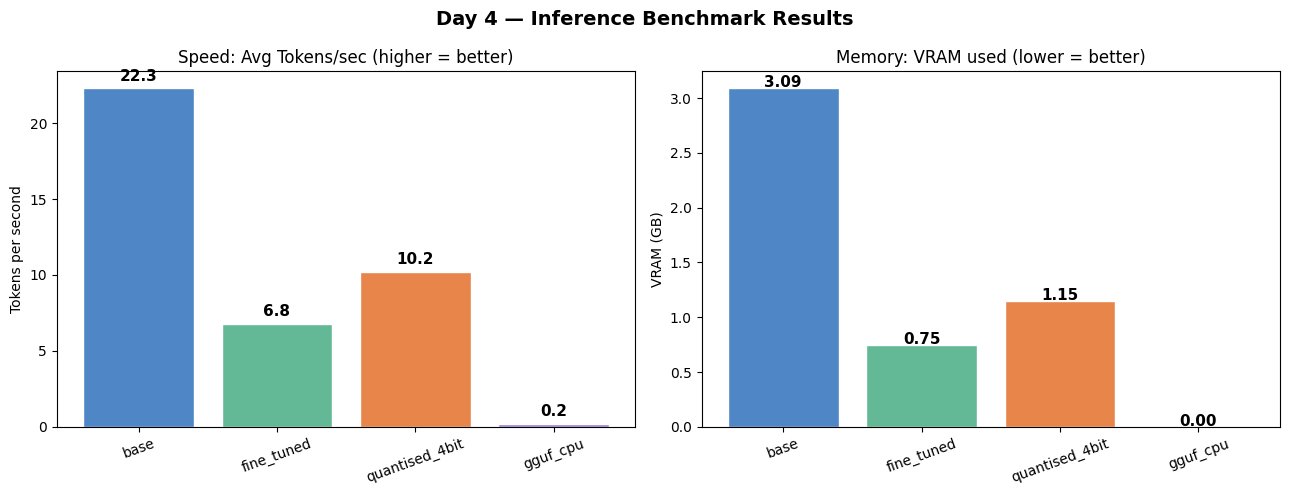

✅ Graph saved: /content/drive/MyDrive/Colab Notebooks/Week8/benchmarks/benchmark_comparison.png


In [ ]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


model_names, avg_tps, avg_vram = [], [], []

groups = {
    'base':          base_results,
    'fine_tuned':    fine_tuned_results,
    'quantised_4bit': quant_results,
}
if 'gguf_results_list' in dir() and gguf_results_list:
    groups['gguf_cpu'] = gguf_results_list

for name, rows in groups.items():
    if rows:
        model_names.append(name)
        avg_tps.append(round(sum(r['tokens_per_sec'] for r in rows) / len(rows), 1))
        avg_vram.append(rows[0]['vram_gb'])

colors = ['#4F86C6', '#63B995', '#E8854A', '#9B7FD4']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Day 4 — Inference Benchmark Results', fontsize=14, fontweight='bold')

# Speed
bars1 = axes[0].bar(model_names, avg_tps, color=colors[:len(model_names)], edgecolor='white')
axes[0].set_title('Speed: Avg Tokens/sec (higher = better)')
axes[0].set_ylabel('Tokens per second')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars1, avg_tps):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(v), ha='center', fontsize=11, fontweight='bold')

# VRAM
bars2 = axes[1].bar(model_names, avg_vram, color=colors[:len(model_names)], edgecolor='white')
axes[1].set_title('Memory: VRAM used (lower = better)')
axes[1].set_ylabel('VRAM (GB)')
axes[1].tick_params(axis='x', rotation=20)
for bar, v in zip(bars2, avg_vram):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
graph_path = f'{OUTPUT_DIR}/benchmark_comparison.png'
plt.savefig(graph_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Graph saved: {graph_path}')

In [ ]:

SAVE_TO_DRIVE = False   

if SAVE_TO_DRIVE:
    import shutil
    drive_dest = '/content/drive/MyDrive/Week8/Day4'
    os.makedirs(drive_dest, exist_ok=True)
    shutil.copy(csv_path, drive_dest)
    shutil.copy(graph_path, drive_dest)
    print(f'✅ Files saved to Drive: {drive_dest}')
else:
    print('Tip: SAVE_TO_DRIVE = True karo taaki results Drive mein save hon!')

Tip: SAVE_TO_DRIVE = True karo taaki results Drive mein save hon!
